In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df=pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [98]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [99]:
drop_cols = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df.drop(columns=drop_cols, inplace=True)

In [100]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [101]:
df.shape

(1470, 31)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [103]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [104]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1465,False
1466,False
1467,False
1468,False


In [105]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object


In [106]:
df.select_dtypes(include='object').columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [107]:
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

In [108]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [109]:
df['Gender'] = df['Gender'].map({
    'Male': 1,
    'Female': 0
})

In [110]:
df['Gender'].value_counts()

,count
Gender,
1,882
0,588


In [111]:
df['OverTime'] = df['OverTime'].map({
    'Yes': 1,
    'No': 0
})

In [112]:
df['OverTime'].value_counts()

,count
OverTime,
0,1054
1,416


In [113]:
categorical_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus'
]

In [114]:
df=pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [115]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

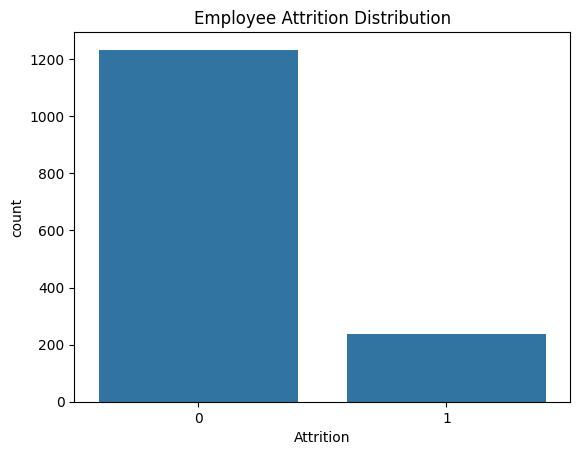

In [117]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

In [118]:
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
0,83.877551
1,16.122449


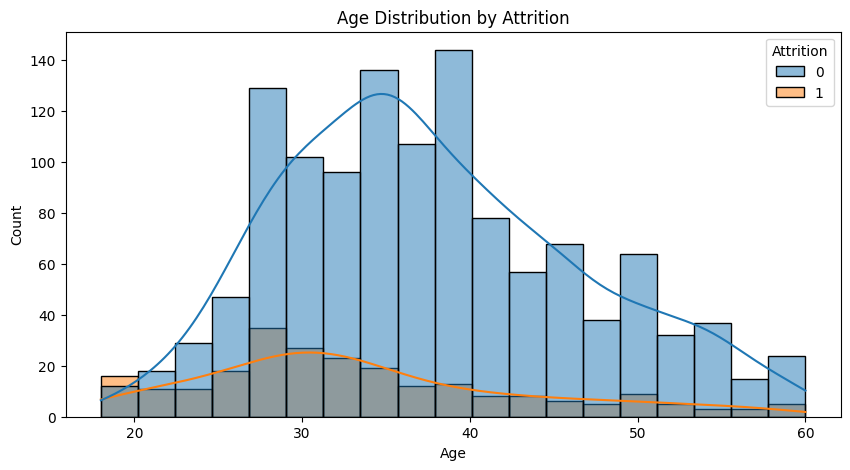

In [119]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True)
plt.title("Age Distribution by Attrition")
plt.show()

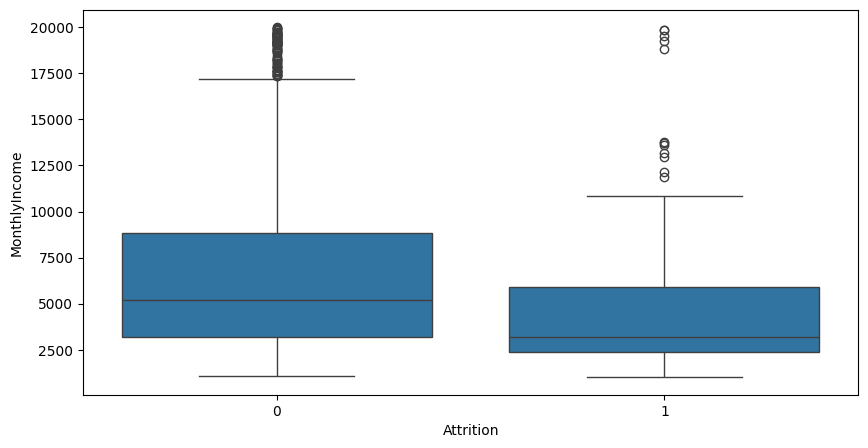

In [120]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.show()

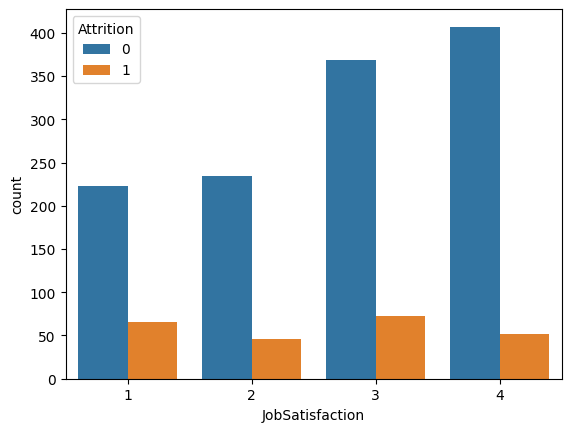

In [121]:
sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df
)

plt.show()

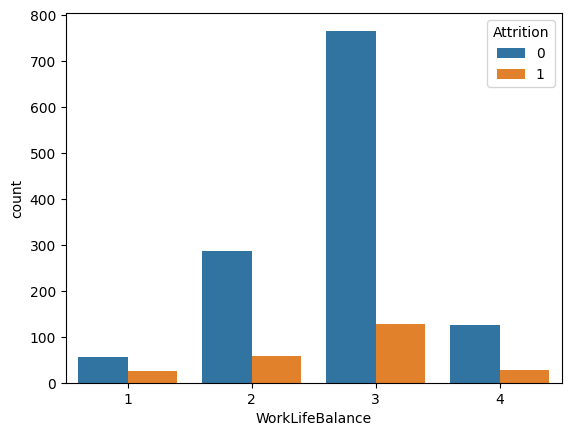

In [122]:
sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)

plt.show()

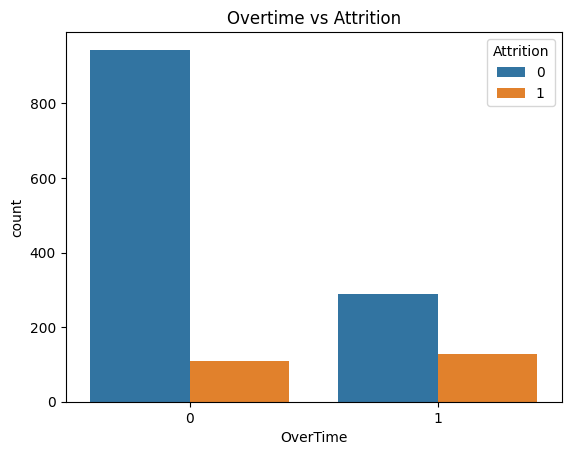

In [123]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Overtime vs Attrition")
plt.show()

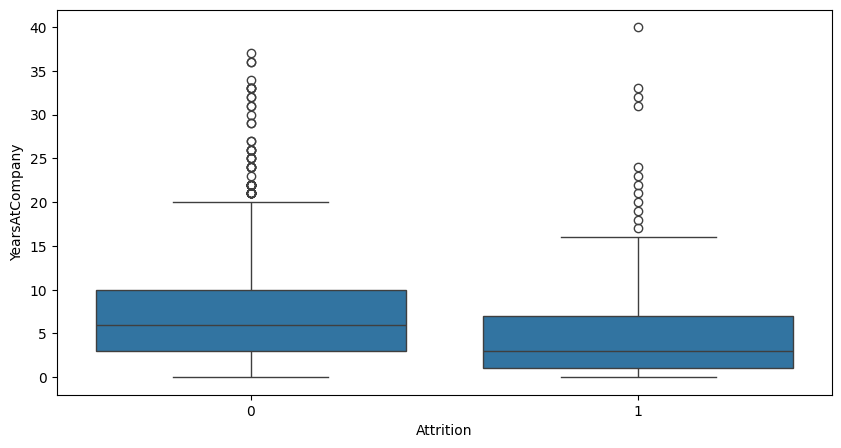

In [124]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)

plt.show()

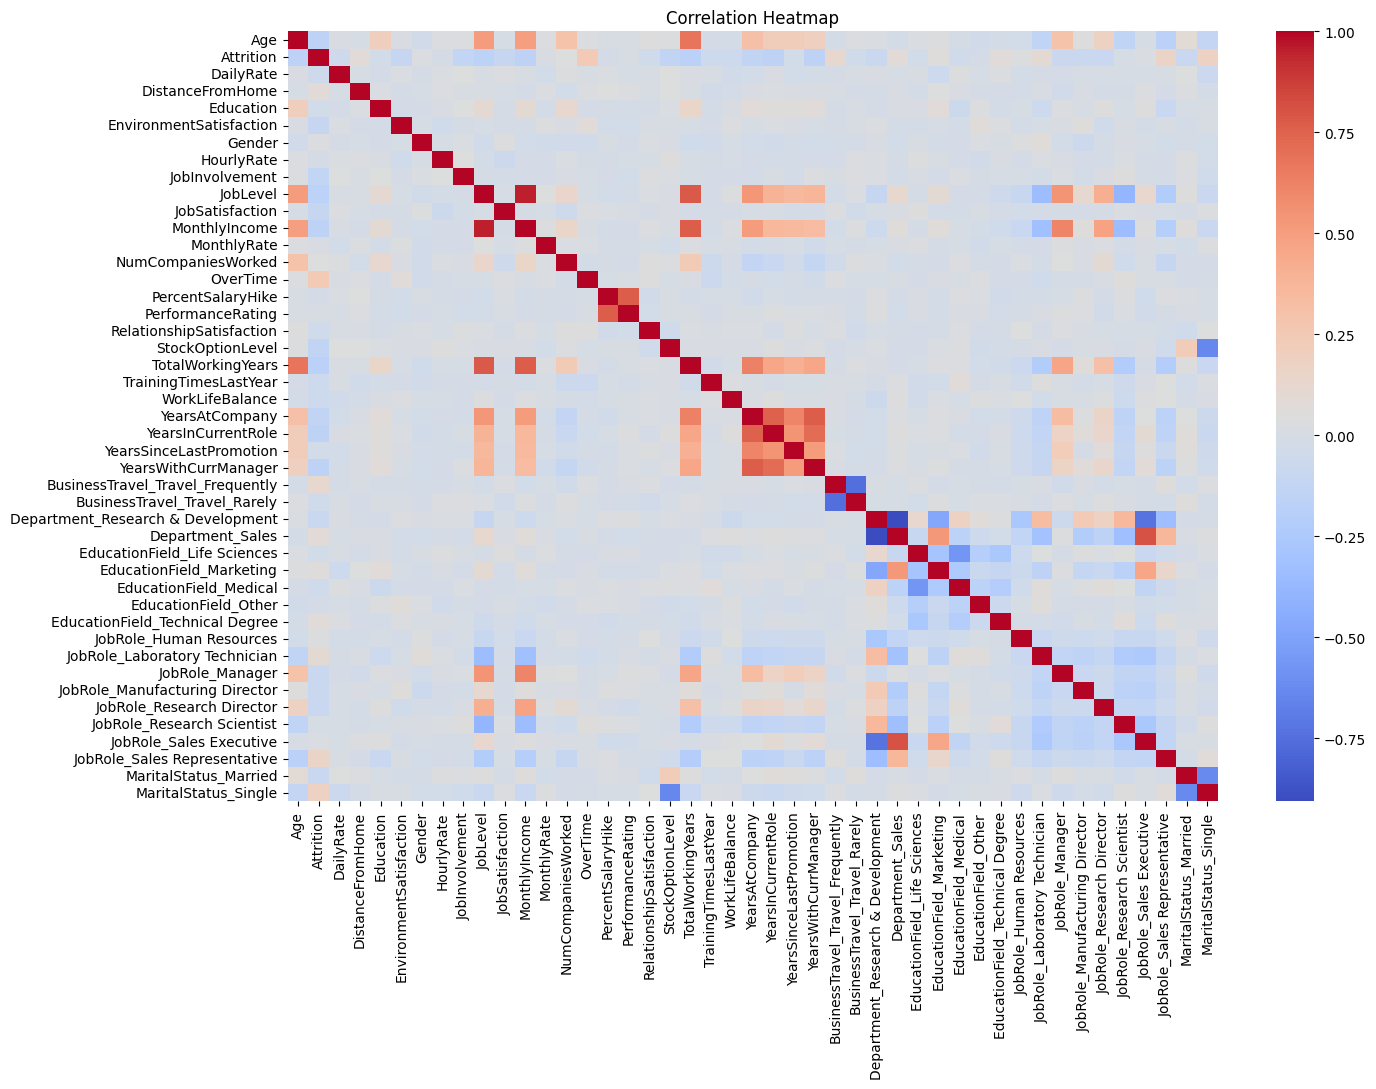

In [125]:
plt.figure(figsize=(15,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [126]:
corr = df.corr(numeric_only=True)

attrition_corr = corr['Attrition']

print(
    attrition_corr.sort_values(
        ascending=False
    )
)

Attrition                            1.000000
OverTime                             0.246118
MaritalStatus_Single                 0.175419
JobRole_Sales Representative         0.157234
BusinessTravel_Travel_Frequently     0.115143
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
DistanceFromHome                     0.077924
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
NumCompaniesWorked                   0.043494
JobRole_Human Resources              0.036215
Gender                               0.029453
JobRole_Sales Executive              0.019774
MonthlyRate                          0.015170
PerformanceRating                    0.002889
JobRole_Research Scientist          -0.000360
HourlyRate                          -0.006846
PercentSalaryHike                   -0.013478
EducationField_Other                -0.017898
Education                           -0.031373
EducationField_Life Sciences      

In [127]:
corr = df.corr(numeric_only=True)

top_features = (
    corr['Attrition']
    .abs()
    .sort_values(ascending=False)
)

print(top_features.head(15))

Attrition                           1.000000
OverTime                            0.246118
MaritalStatus_Single                0.175419
TotalWorkingYears                   0.171063
JobLevel                            0.169105
YearsInCurrentRole                  0.160545
MonthlyIncome                       0.159840
Age                                 0.159205
JobRole_Sales Representative        0.157234
YearsWithCurrManager                0.156199
StockOptionLevel                    0.137145
YearsAtCompany                      0.134392
JobInvolvement                      0.130016
BusinessTravel_Travel_Frequently    0.115143
JobSatisfaction                     0.103481
Name: Attrition, dtype: float64


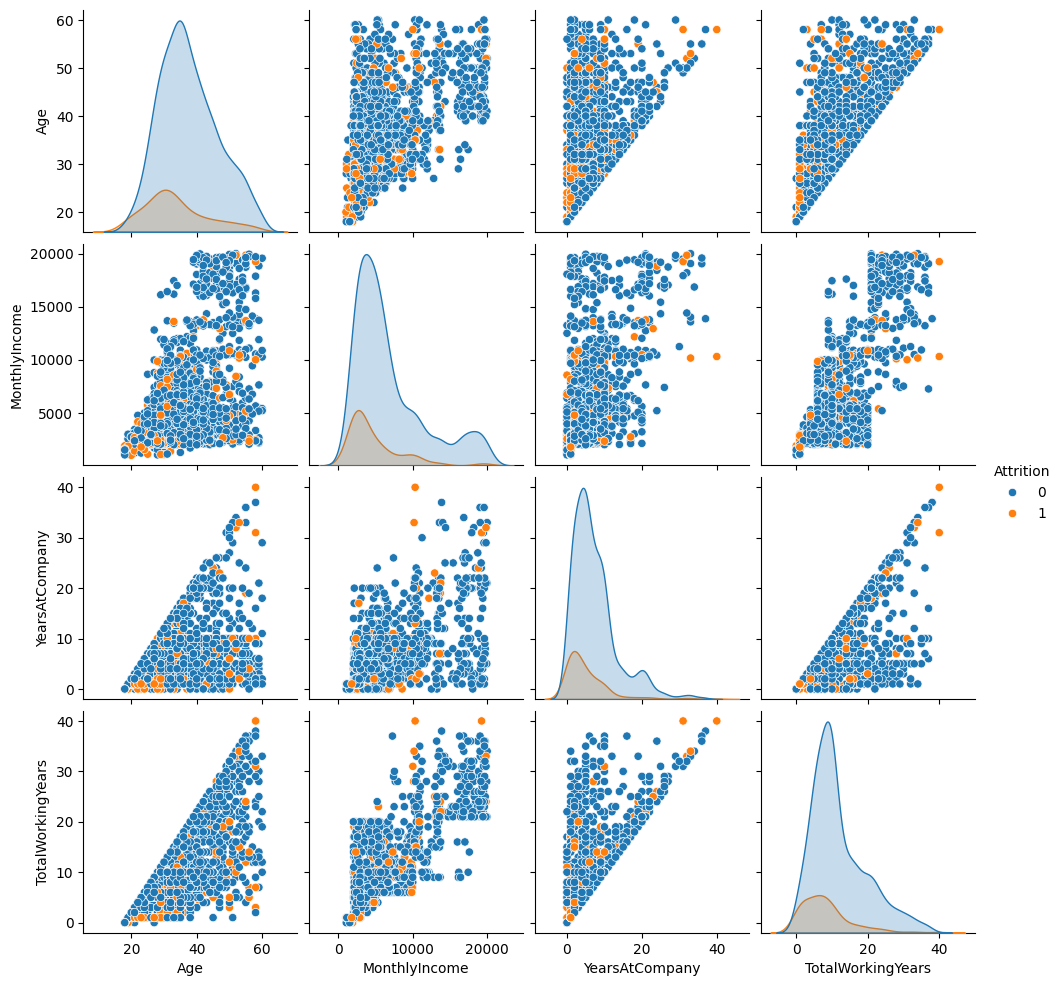

In [128]:
important_cols = [
    'Age',
    'MonthlyIncome',
    'YearsAtCompany',
    'TotalWorkingYears',
    'Attrition'
]

sns.pairplot(
    df[important_cols],
    hue='Attrition'
)

plt.show()

In [129]:
pip install ydata-profiling

In [130]:
rom ydata_profiling import ProfileReport
profile = ProfileReport(
    df,
    title="Employee Attrition EDA Report",
    explorative=True
)

SyntaxError: invalid syntax (1090504766.py, line 1)

In [131]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [132]:
print(X.shape)
print(y.shape)

(1470, 44)
(1470,)


In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [137]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

In [138]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [140]:
y_pred_lr = lr.predict(X_test)

In [141]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.8775510204081632
Precision: 0.5483870967741935
Recall   : 0.4358974358974359
F1 Score : 0.4857142857142857


In [142]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm)

[[241  14]
 [ 22  17]]


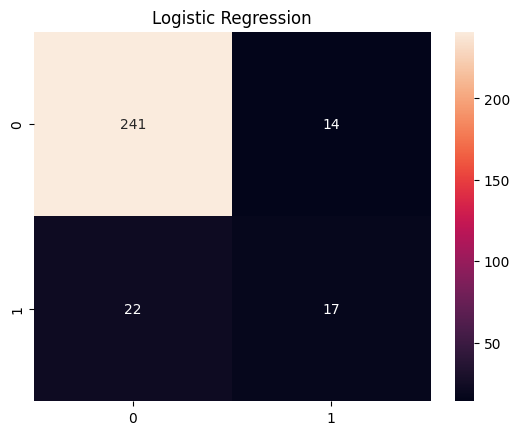

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression")
plt.show()

In [144]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [145]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7482993197278912


In [146]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [147]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8809523809523809


In [148]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.877551
1,Decision Tree,0.748299
2,Random Forest,0.880952


In [149]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                  Feature  Importance
10          MonthlyIncome    0.074004
13               OverTime    0.061448
0                     Age    0.054427
1               DailyRate    0.051906
18      TotalWorkingYears    0.047909
11            MonthlyRate    0.047704
2        DistanceFromHome    0.045275
6              HourlyRate    0.043266
21         YearsAtCompany    0.040355
12     NumCompaniesWorked    0.034802
14      PercentSalaryHike    0.034692
24   YearsWithCurrManager    0.034409
17       StockOptionLevel    0.029392
22     YearsInCurrentRole    0.028436
19  TrainingTimesLastYear    0.026417


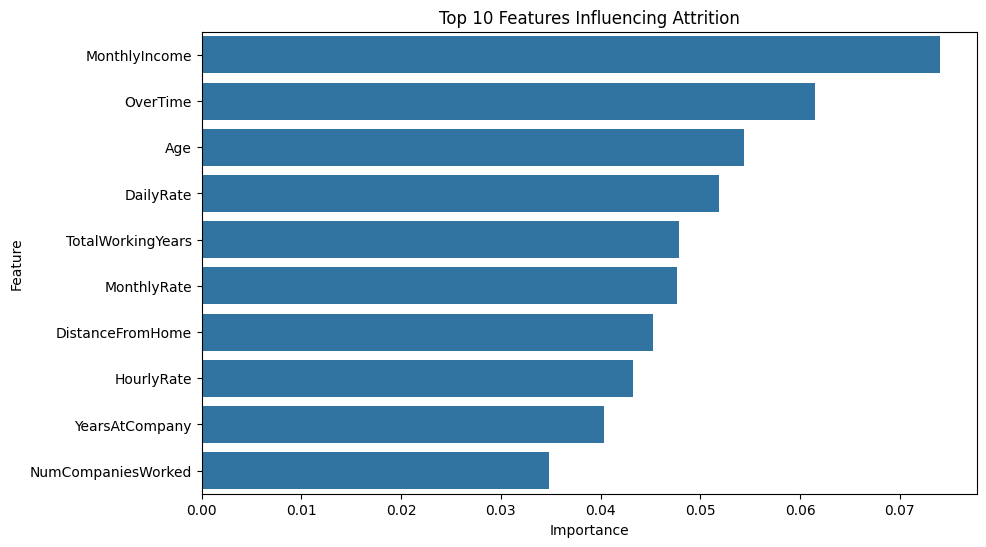

In [150]:
top = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Features Influencing Attrition"
)

plt.show()

In [151]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       1.00      0.10      0.19        39

    accuracy                           0.88       294
   macro avg       0.94      0.55      0.56       294
weighted avg       0.90      0.88      0.84       294



In [152]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

final_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [153]:
import pickle

# Save model
with open("employee_attrition_model.pkl", "wb") as file:
    pickle.dump(rf, file)

print("Model saved successfully!")

Model saved successfully!


In [154]:
import pickle

with open("employee_attrition_model.pkl", "rb") as file:
    model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [156]:
with open("feature_names.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

In [157]:
with open("feature_names.pkl", "rb") as file:
    feature_names = pickle.load(file)